In [1]:
from src.model.MultiU_NetModel import MultiU_Net
from src.training.out_conv_training.SortingMethod import BEST_PERM
from src.model.MaskTransform import multi_class_post_process
from src.model.MaskVisualization import segmentation_visualizer


In [2]:
try:
    import kagglehub
except ImportError:
    !pip install kagglehub

import torch

from src.benchmark.ModelBenchmark import evaluate_model_on_dataset
from src.dataset.DroneSegDataSet import MyDataset
from src.dataset.CheckDataset import check_dataset
from torchvision import transforms

# 加载数据集
ds_path = check_dataset()
dataset = MyDataset(
    'drone_seg_dataset/classes_dataset/classes_dataset/original_images',
    'drone_seg_dataset/classes_dataset/classes_dataset/label_images_semantic',
    transform=transforms.Compose([
        transforms.ToTensor(),
    ]),
    # data_enforcement=True,
)

n_classes = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


当前脚本路径: /home/jovyan/2026.3.25_BBC6521_DroneSegModel/src/dataset
项目根路径: /home/jovyan/2026.3.25_BBC6521_DroneSegModel
Dataset already exists.
成功匹配文件: 174.png, 498.png, 590.png 等 400 个文件


torch.Size([3, 736, 960])
torch.Size([3, 736, 960])
torch.Size([3, 736, 960])
torch.Size([3, 736, 960])
torch.Size([3, 736, 960])


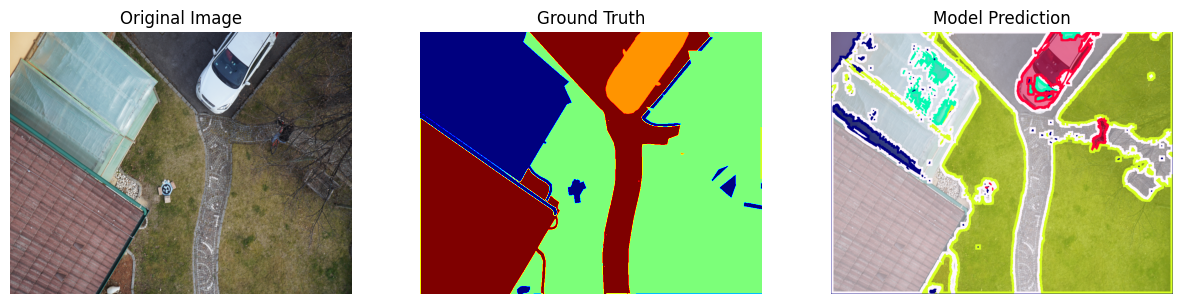

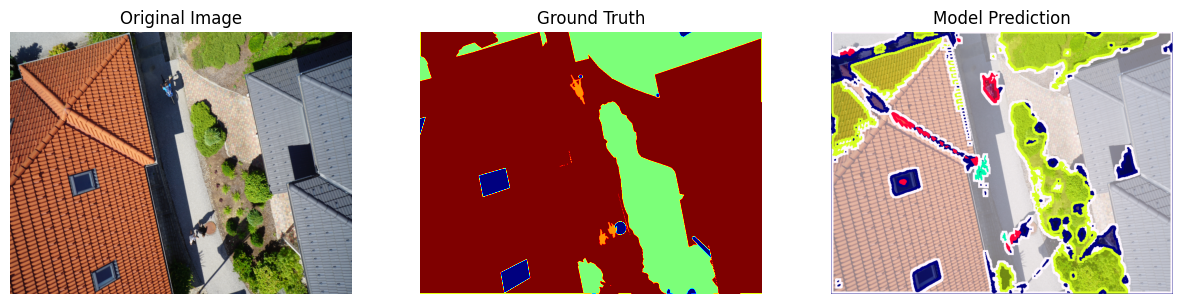

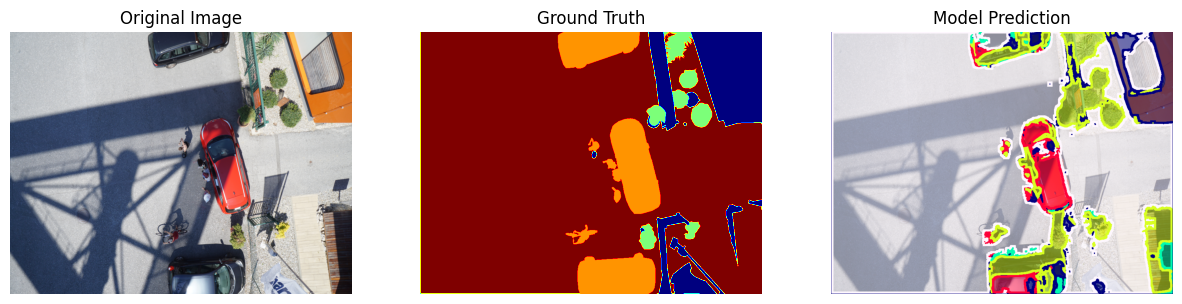

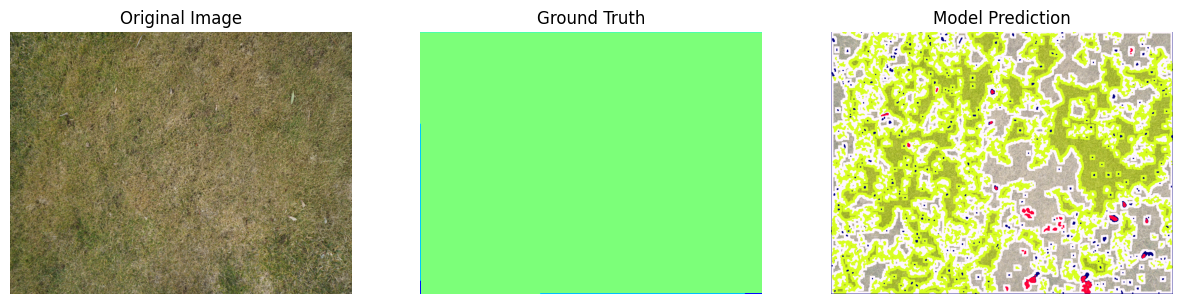

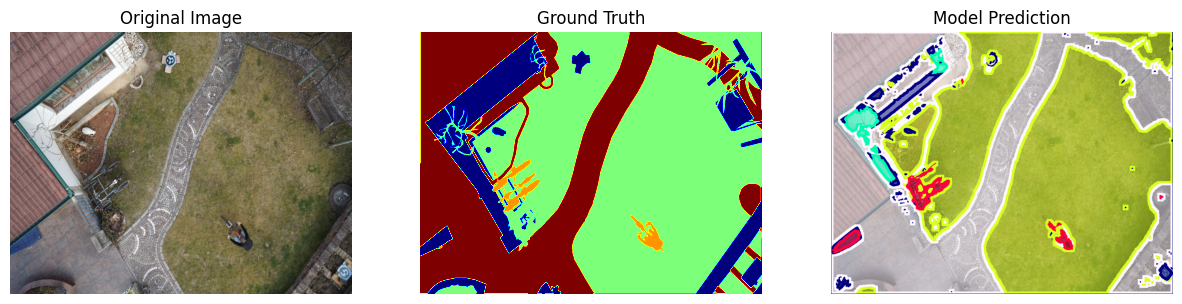

In [6]:
# 数据集大小400 随机获取5个样本的索引
import random
sample_indices = random.sample(range(len(dataset)), 5)

from src.model.MultiU_NetModel import MultiU_Net
model = MultiU_Net(
    in_channel=22,
    depth=[3] * 5,
    depthwise_separable=False,
    combine_method='out_layer',
).to(device)

import os
para_dir = 'resources/para'
para_list = [
    os.path.join(para_dir, 'unet_branch0.pth'),
    os.path.join(para_dir, 'unet_branch1.pth'),
    os.path.join(para_dir, 'unet_branch2.pth'),
    os.path.join(para_dir, 'unet_branch3.pth'),
    os.path.join(para_dir, 'unet_branch4.pth'),
]
out_para = os.path.join(para_dir, 'out_conv.pth')
model.read_param(para_list, out_para)

for idx in sample_indices:
    feat_img, label, img = dataset.__getitem__(idx)

    feat_img = feat_img.unsqueeze(0).to(device) # 添加批次维度
    with torch.no_grad():
        output = model(feat_img)

    fixed_output = multi_class_post_process(torch.argmax(output, dim=1), BEST_PERM)

    # 可视化
    print(img.shape)
    visualized = segmentation_visualizer(
        image=img.unsqueeze(0),
        mask=fixed_output.cpu(), # 去除批次维度
    )

    # 展示可视化的图片、原图、标签
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0)) # 转换为 HWC 格式
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(label.cpu(), cmap='jet', vmin=0, vmax=n_classes-1)
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    axes[2].imshow(visualized)
    axes[2].set_title('Model Prediction')
    axes[2].axis('off')


In [4]:
# 遍历所有样本，检查哪些样本上表现最好，通过数据集中的文件名输出所有可以拿来展示的图片。

ans_list = []

from torch.utils.data import DataLoader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

for batch_idx, (feat_img, label, img) in enumerate(dataloader):
    feat_img = feat_img.to(device)
    with torch.no_grad():
        output = model(feat_img)

    fixed_output = multi_class_post_process(torch.argmax(output, dim=1), BEST_PERM)

    # 检查正确率和miou

    def check_accuracy(pred, label):
        correct = (pred == label).sum().item()
        total = label.numel()
        return correct / total
    def check_miou(pred, label, n_classes):
        ious = []
        for cls in range(n_classes):
            pred_cls = (pred == cls)
            label_cls = (label == cls)
            intersection = (pred_cls & label_cls).sum().item()
            union = (pred_cls | label_cls).sum().item()
            if union > 0:
                ious.append(intersection / union)
        return sum(ious) / len(ious) if ious else 0

    acc = check_accuracy(fixed_output.cpu(), label.cpu())
    miou = check_miou(fixed_output.cpu(), label.cpu(), n_classes)

    file_name = dataset.get_file_name(batch_idx)

    ans_list.append((file_name, acc, miou))

# 按照准确率排序
ans_list.sort(key=lambda x: x[1], reverse=True)
# 输出前 40 个表现最好的图片名称
for i in range(40):
    print(ans_list[i][0], ans_list[i][1], ans_list[i][2])


063.png 0.9592971580615942 0.4820217430945374
314.png 0.9581748188405798 0.823485547504107
117.png 0.9516431725543478 0.509597903632738
109.png 0.9481431159420289 0.5235070197403003
158.png 0.9466796875 0.5605197409648943
326.png 0.9464433310688406 0.4841875915526385
101.png 0.9447987432065217 0.6173612225067201
281.png 0.9414515398550725 0.5926564711471811
491.png 0.9409958106884058 0.6061678103918081
079.png 0.9396838201992753 0.6960394040702025
118.png 0.9362884963768116 0.5631439796754678
004.png 0.9356954823369565 0.6007985987703542
011.png 0.9346608922101449 0.6263744806051459
323.png 0.9335215692934783 0.5834216700991484
391.png 0.9335116621376811 0.5924026541990202
596.png 0.9320807857789855 0.6285497557926996
573.png 0.9315995810688406 0.4592729636953952
332.png 0.9303611865942029 0.7180260024404976
434.png 0.9303102355072463 0.6019199488128122
507.png 0.9291751585144927 0.38260224396610265
590.png 0.9285594995471015 0.44175457658388434
549.png 0.9279495018115942 0.64113574712